 # <span style="color: #3674B5; font-family: Georgia; font-size: 24px; text-shadow: 1px 1px 2px #FFD166">NoteBook Imports</span>

In [1]:
import os
from os import walk
from os.path import join
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

import nltk

from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from IPython.display import display 

from bs4 import BeautifulSoup # for html tags
from wordcloud import WordCloud
from PIL import Image

from sklearn.model_selection import train_test_split

%matplotlib inline

# <span style="color: #FF6B6B; font-family: Georgia; font-size: 45px; text-shadow: 1px 1px 2px #FFD166">✨ Gather Data ✨</span>

# <span style="color: #3674B5; font-family: Georgia; font-size: 24px; text-shadow: 1px 1px 2px #FFD166">Constant</span>

In [2]:
EXAMPLE_FILE = '2.1 SpamData/01_Processing/practice_email.txt'


SPAM_1_PATH = '2.1 SpamData/01_Processing/spam_assassin_corpus/spam_1'
SPAM_2_PATH = '2.1 SpamData/01_Processing/spam_assassin_corpus/spam_2'
EASY_NONSPAM_1_PATH = '2.1 SpamData/01_Processing/spam_assassin_corpus/easy_ham_1'
EASY_NONSPAM_2_PATH = '2.1 SpamData/01_Processing/spam_assassin_corpus/easy_ham_2'
SPAM_CAT = 1
HAM_CAT = 0
VOCAB_SIZE = 2500

DATA_JSON_FILE = '2.1 SpamData/01_Processing/email-text-data.json'
WORD_ID_FILE = '2.1 SpamData/01_Processing/word-by-id.csv'
WORD_ID_FILE = '2.1 SpamData/01_Processing/word-by-id.csv'

TRAINING_DATA_FILE=   '2.1 SpamData/02_Training/train-data.txt'
TEST_DATA_FILE=   '2.1 SpamData/02_Training/test-data.txt'

WHALE_FILE = '2.1 SpamData/01_Processing/wordcloud_resources/whale-icon.png'
SKULL_FILE = '2.1 SpamData/01_Processing/wordcloud_resources/skull-icon.png'
THUMBS_UP_FILE = '2.1 SpamData/01_Processing/wordcloud_resources/thumbs-up.png'
THUMBS_DOWN_FILE = '2.1 SpamData/01_Processing/wordcloud_resources/thumbs-down.png'

  # <span style="color: #3674B5; font-family: Georgia; font-size: 24px; text-shadow: 1px 1px 2px #FFD166">Reading Files</span>

In [3]:
stream = open(EXAMPLE_FILE, encoding='latin-1')
message = stream.read()
stream.close()

print(type(message))
print(message)

<class 'str'>
From exmh-workers-admin@redhat.com  Thu Aug 22 12:36:23 2002
Return-Path: <exmh-workers-admin@spamassassin.taint.org>
Delivered-To: zzzz@localhost.netnoteinc.com
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.netnoteinc.com (Postfix) with ESMTP id D03E543C36
	for <zzzz@localhost>; Thu, 22 Aug 2002 07:36:16 -0400 (EDT)
Received: from phobos [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Thu, 22 Aug 2002 12:36:16 +0100 (IST)
Received: from listman.spamassassin.taint.org (listman.spamassassin.taint.org [66.187.233.211]) by
    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g7MBYrZ04811 for
    <zzzz-exmh@spamassassin.taint.org>; Thu, 22 Aug 2002 12:34:53 +0100
Received: from listman.spamassassin.taint.org (localhost.localdomain [127.0.0.1]) by
    listman.redhat.com (Postfix) with ESMTP id 8386540858; Thu, 22 Aug 2002
    07:35:02 -0400 (EDT)
Delivered-To: exmh-workers@listman.spamassassin.taint.org
Received: fro

In [4]:
import sys 
sys.getfilesystemencoding ()

'utf-8'

In [5]:
stream = open(EXAMPLE_FILE, encoding='latin-1')

is_body = False
lines = []
for line in stream:
    if line == '\n': 
        is_body = True
    elif is_body:  
        lines.append(line)

stream.close()

email_body = '\n'.join(lines)
print(email_body)

Dear Mr Still

Good tidings to you and all your staff for the festive season ahead (Christmas).

Now to the crux of the matter-in-hand: I am a fully qualified Santa Claus and am wondering whether you might consider me to run my own "Santa's Grotto" in your store.

But WAIT! You're probably thinking: "What makes him so special?"

Well, first of all, I have made several changes to the characterisation of Father Christmas. Rather than greeting the children with shouts of "Ho, ho, ho!" I prefer to whisper the phrase "Dependence is not unfathomable in this cruel world we live in". In addition, my gifts are ALL hand-made, ranging from felt hoops to vanilla-pod holders.

You will note also, from the enclosed sketch, that I have radically redesigned Santa's outfit and have renamed my character "Lord Buckles". Would you be interested in employing me? I promise NEVER to let you down.

I look forward to hearing from you.

Best wishes

Robin Cooper

[Excerpt from the book: The Timewaster Letters b

In [6]:
stream = open(EXAMPLE_FILE, encoding='latin-1')

is_body = False
lines = []

for line in stream:
    if is_body:
        lines.append(line)
    elif line == '\n':
        is_body = True

stream.close()

# email_body = '\n'.join(lines)
# print(email_body)
print(lines)

['\n', 'Dear Mr Still\n', '\n', 'Good tidings to you and all your staff for the festive season ahead (Christmas).\n', 'Now to the crux of the matter-in-hand: I am a fully qualified Santa Claus and am wondering whether you might consider me to run my own "Santa\'s Grotto" in your store.\n', 'But WAIT! You\'re probably thinking: "What makes him so special?"\n', 'Well, first of all, I have made several changes to the characterisation of Father Christmas. Rather than greeting the children with shouts of "Ho, ho, ho!" I prefer to whisper the phrase "Dependence is not unfathomable in this cruel world we live in". In addition, my gifts are ALL hand-made, ranging from felt hoops to vanilla-pod holders.\n', 'You will note also, from the enclosed sketch, that I have radically redesigned Santa\'s outfit and have renamed my character "Lord Buckles". Would you be interested in employing me? I promise NEVER to let you down.\n', 'I look forward to hearing from you.\n', '\n', 'Best wishes\n', 'Robin C

  # <span style="color: #3674B5; font-family: Georgia; font-size: 30px; text-shadow: 1px 1px 2px #FFD166"> Generator Functions </span>

In [7]:

def generate_squares(N):
    for my_number in range(N):
        yield my_number ** 2

In [8]:
for i in generate_squares(5):
    print(i, end='->')

0->1->4->9->16->

  # <span style="color: #3674B5; font-family: Georgia; font-size: 30px; text-shadow: 1px 1px 2px #FFD166">Email Body Extraction </span>

In [9]:
def email_body_generator(path):

    for root, dirnames, filenames in walk(path):
        for file_name in filenames:

            filepath = join(root, file_name)

            stream = open(filepath, encoding='latin-1')

            is_body = False
            lines = []

            for line in stream:
                if is_body:
                    lines.append(line)
                elif line == '\n':
                    is_body = True

            stream.close()

            email_body = '\n'.join(lines)

            yield file_name, email_body

In [10]:
def df_from_directory(path, classification):
    rows = []
    row_names = []

    for file_name, email_body in email_body_generator(path):
        rows.append({'MESSAGE': email_body, 'CATEGORY': classification})
        row_names.append(file_name)

    return pd.DataFrame(rows, index=row_names)

In [11]:
# Method 1: Using pd.concat() (recommended)
spam_emails = df_from_directory(SPAM_1_PATH, 1)
spam_emails = pd.concat([spam_emails, df_from_directory(SPAM_2_PATH, 1)])
spam_emails.head()

,MESSAGE,CATEGORY
00249.5f45607c1bffe89f60ba1ec9f878039a,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",1
00373.ebe8670ac56b04125c25100a36ab0510,ATTENTION: This is a MUST for ALL Computer Use...,1
00214.1367039e50dc6b7adb0f2aa8aba83216,This is a multi-part message in MIME format.\n...,1
00210.050ffd105bd4e006771ee63cabc59978,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,1
00033.9babb58d9298daa2963d4f514193d7d6,This is the bottom line. If you can GIVE AWAY...,1


In [12]:
spam_emails.shape

(1898, 2)

In [13]:
# Create dataframe for non-spam emails
ham_emails = df_from_directory(EASY_NONSPAM_1_PATH, HAM_CAT)

# Combine with second directory
ham_emails = pd.concat([
    ham_emails,
    df_from_directory(EASY_NONSPAM_2_PATH, HAM_CAT)
])

# Print the shape
print(f"Shape of non-spam emails dataframe: {ham_emails.shape}")

Shape of non-spam emails dataframe: (3900, 2)


In [14]:
data = pd.concat([spam_emails, ham_emails])
print('Shape Of Entire DataFrame is', data.shape)
data.head()

Shape Of Entire DataFrame is (5798, 2)


,MESSAGE,CATEGORY
00249.5f45607c1bffe89f60ba1ec9f878039a,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",1
00373.ebe8670ac56b04125c25100a36ab0510,ATTENTION: This is a MUST for ALL Computer Use...,1
00214.1367039e50dc6b7adb0f2aa8aba83216,This is a multi-part message in MIME format.\n...,1
00210.050ffd105bd4e006771ee63cabc59978,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,1
00033.9babb58d9298daa2963d4f514193d7d6,This is the bottom line. If you can GIVE AWAY...,1


In [15]:
data.tail()

,MESSAGE,CATEGORY
00609.dd49926ce94a1ea328cce9b62825bc97,"I'm one of the 30,000 but it's not working ver...",0
00957.e0b56b117f3ec5f85e432a9d2a47801f,Damien Morton quoted:\n\n>W3C approves HTML 4 ...,0
01127.841233b48eceb74a825417d8d918abf8,"On Mon, 2002-07-22 at 06:50, che wrote:\n\n\n\...",0
01178.5c977dff972cd6eef64d4173b90307f0,"Once upon a time, Manfred wrote :\n\n\n\n> I w...",0
00747.352d424267d36975a7b40b85ffd0885e,"If you run Pick, and then use the ""New FTOC"" b...",0


# <span style="color: #FF6B6B; font-family: Georgia; font-size: 48px; text-shadow: 1px 1px 2px #FFD166">✨ Data Cleaning ✨</span>

 # <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166"> Checking For Missing Values  </span>

In [16]:
# Check if any message bodies are null
data['MESSAGE'].isnull().values.any()


np.False_

In [17]:
type("")

str

In [18]:
len("")

0

In [19]:
my_var = None

In [20]:
type(my_var)

NoneType

In [21]:
# Check if there are empty emails (string length zero)
(data.MESSAGE.str.len() == 0).any()  

np.True_

In [22]:
# there are 3 empty in all rows.
(data.MESSAGE.str.len() == 0).sum()

np.int64(3)

In [23]:
data.MESSAGE.isnull().sum()

np.int64(0)

In [24]:
data[data.MESSAGE.str.len() == 0].index 

Index(['cmds', 'cmds', 'cmds'], dtype='object')

 # <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">  Remove system file entries from Dataframe   </span>

In [25]:
data.drop(['cmds'], inplace=True)


In [26]:
data.shape


(5795, 2)

# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">  Add Document IDs to Track Emails in Dataset  </span>

In [27]:
document_ids = range(0, len(data.index))
data['DOC_ID'] = document_ids


In [28]:
data['FILE_NAME'] = data.index
data.set_index('DOC_ID', inplace=True)
data.head()

,MESSAGE,CATEGORY,FILE_NAME
DOC_ID,,,
0,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",1,00249.5f45607c1bffe89f60ba1ec9f878039a
1,ATTENTION: This is a MUST for ALL Computer Use...,1,00373.ebe8670ac56b04125c25100a36ab0510
2,This is a multi-part message in MIME format.\n...,1,00214.1367039e50dc6b7adb0f2aa8aba83216
3,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,1,00210.050ffd105bd4e006771ee63cabc59978
4,This is the bottom line. If you can GIVE AWAY...,1,00033.9babb58d9298daa2963d4f514193d7d6


In [29]:
data.tail()

,MESSAGE,CATEGORY,FILE_NAME
DOC_ID,,,
5790,"I'm one of the 30,000 but it's not working ver...",0,00609.dd49926ce94a1ea328cce9b62825bc97
5791,Damien Morton quoted:\n\n>W3C approves HTML 4 ...,0,00957.e0b56b117f3ec5f85e432a9d2a47801f
5792,"On Mon, 2002-07-22 at 06:50, che wrote:\n\n\n\...",0,01127.841233b48eceb74a825417d8d918abf8
5793,"Once upon a time, Manfred wrote :\n\n\n\n> I w...",0,01178.5c977dff972cd6eef64d4173b90307f0
5794,"If you run Pick, and then use the ""New FTOC"" b...",0,00747.352d424267d36975a7b40b85ffd0885e


# <span style="color: #FF6B6B; font-family: Georgia; font-size: 48px">✨ Explore & Visualize ✨</span> 



# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">  Save To File Using Pandas </span>

In [30]:
data.to_json(DATA_JSON_FILE)


# <span style="color: #3674B5; font-family: Georgia; font-size: 30px; text-shadow: 1px 1px 2px #FFD166"> Number Of Spam Messages Visualised (Pie Charts)  </span>

In [31]:
data.CATEGORY.value_counts()

CATEGORY
0    3899
1    1896
Name: count, dtype: int64

In [32]:

amount_of_spam = data.CATEGORY.value_counts()[1]
amount_of_ham = data.CATEGORY.value_counts()[0]
 

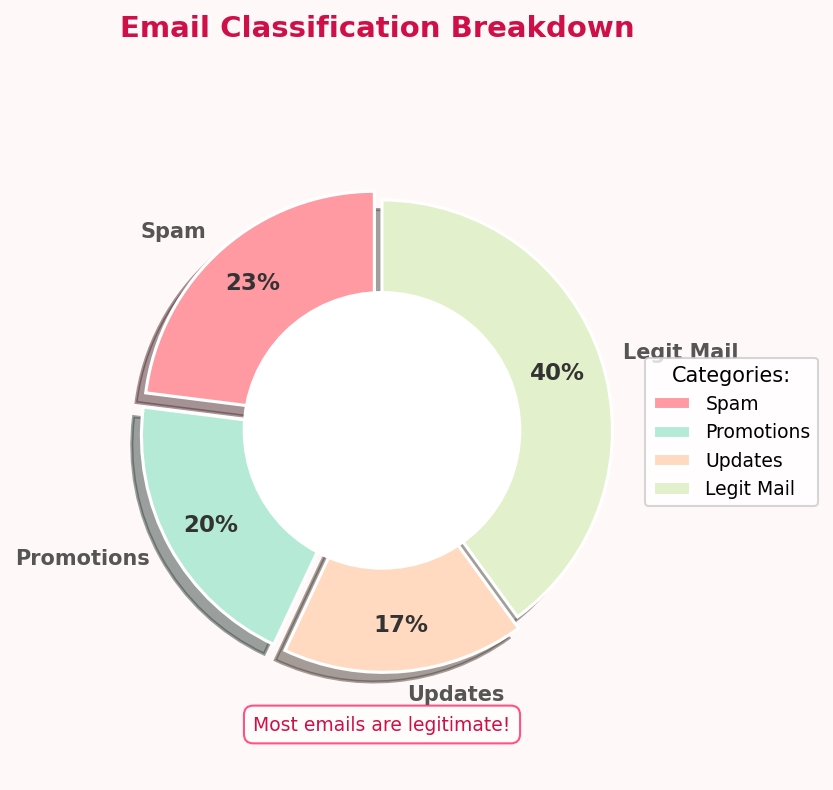

In [33]:
#  universal font
plt.rcParams['font.family'] = 'DejaVu Sans'

# Data with your exact proportions
categories = ['Spam', 'Promotions', 'Updates', 'Legit Mail']
sizes = [23, 20, 17, 40]  # Sums to 100% (23+20+17+40)
explode = (0.05, 0.05, 0.05, 0)  # Slightly explode first three slices
colors = ['#FF9AA2', '#B5EAD7', '#FFDAC1', '#E2F0CB']  # Cute pastel colors

# Create figure with cute settings
plt.figure(figsize=(5.6, 5.7), facecolor='#FFF8F8', dpi=150)

# Create pie chart with your specifications
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=categories,
    explode=explode,
    colors=colors,
    autopct='%1.0f%%',  # Whole numbers without decimals
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10, 'fontweight': 'bold', 'color': '#555555'},
    shadow=True,
    pctdistance=0.8  # Move percentages inward
)

# Make percentages larger and bold
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('#333333')

# Add donut effect
center_circle = plt.Circle((0,0), 0.6, color='white')
plt.gca().add_artist(center_circle)

# Add title with cute styling
plt.title('Email Classification Breakdown', 
          pad=25, 
          fontsize=14, 
          fontweight='bold', 
          color='#CF0F47')

# Add cute legend
plt.legend(title="Categories:", 
           loc="center left", 
           bbox_to_anchor=(1, 0.5),
           prop={'size': 9})

# Add playful annotation
plt.text(0, -1.3, "Most emails are legitimate!", 
         ha='center', 
         fontsize=9, 
         color='#CF0F47',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='#FF0B55', boxstyle='round,pad=0.5'))

# Equal aspect ratio ensures pie is drawn as circle
plt.axis('equal')  
plt.tight_layout()
plt.show() 




 # <span style="color: #3674B5; font-family: Georgia; font-size: 29px; text-shadow: 1px 1px 2px #FFD166"> Natural Language Processing   </span>

 # <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166"> Text Pre-Processing   </span>

In [34]:
# convert to lower case
msg = 'All work an no play makes Jack a dull boy.'
msg.lower()

'all work an no play makes jack a dull boy.'

 # <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166"> Download the NLTK Resources (Tokenizer & Stopwords)   </span>

In [35]:

nltk.download('punkt_tab')  # Download the missing supplementary data
nltk.download('punkt')      # Ensure main punkt tokenizer is installed

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/somiasohail/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/somiasohail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [36]:
nltk.download('gutenberg')
nltk.download('shakespeare')

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/somiasohail/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package shakespeare to
[nltk_data]     /Users/somiasohail/nltk_data...
[nltk_data]   Package shakespeare is already up-to-date!


True

# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">  Tokenising </span>

In [37]:
msg = 'All work an no play makes Jack a dull boy.'
tokens = word_tokenize(msg)
print(tokens)

['All', 'work', 'an', 'no', 'play', 'makes', 'Jack', 'a', 'dull', 'boy', '.']



# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">  Removing stop words </span>

In [38]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/somiasohail/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [39]:
stop_words = set(stopwords.words('english'))

In [40]:
type(stop_words)

set

In [41]:
if 'this' in stop_words: print('Found It!')

Found It!


In [42]:
# challange.
if 'hello' not in stop_words: print('Nope.Not in Here')

Nope.Not in Here


In [43]:
msg = 'All work an no play makes Jack a dull boy. To be or not to be.' 
words = word_tokenize(msg.lower())

filtered_words = []
for word in words:
    if word not in stop_words:
        filtered_words.append(word)

print(filtered_words)


['work', 'play', 'makes', 'jack', 'dull', 'boy', '.', '.']



# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">   Word Stems And Stemming </span>

In [44]:
msg = 'All work and no play makes Jack a dull boy. To be or not to be. Nobody expects the Spanish Inquisition!'
words = word_tokenize(msg.lower())

# stemmer = PorterStemmer()
stemmer = SnowballStemmer('english')

filtered_words = []
# Challenge: append non-stop words to filtered_words
for word in words:
    if word not in stop_words:
        stemmed_word = stemmer.stem(word)
        filtered_words.append(stemmed_word)

print(filtered_words)

['work', 'play', 'make', 'jack', 'dull', 'boy', '.', '.', 'nobodi', 'expect', 'spanish', 'inquisit', '!']


# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">   Removing Punctuation  </span>

In [45]:
msg = 'All work and no play makes Jack a dull boy. To be or not to be.????? .Nobody expects the Spanish Inquisition!'
words = word_tokenize(msg.lower())

# stemmer = PorterStemmer()
stemmer = SnowballStemmer('english')

filtered_words = []

for word in words:
    if word not in stop_words and word.isalpha():
        stemmed_word = stemmer.stem(word)
        filtered_words.append(stemmed_word)

print(filtered_words)

['work', 'play', 'make', 'jack', 'dull', 'boy', 'expect', 'spanish', 'inquisit']


# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">Removing HTML tags from Emails</span>

In [46]:

soup = BeautifulSoup(data.at[2, 'MESSAGE'], 'html.parser')
print(soup.prettify())

This is a multi-part message in MIME format.



------=_NextPart_000_1CDC19_01C25366.4B57F3A0

Content-Type: text/plain;

	charset="Windows-1252"

Content-Transfer-Encoding: quoted-printable



 We dare you...

 Try to find a better annuity!

=20

  - 5.40% Guaranteed for 6 Years=0A=

- 6 Year Surrender Charge=0A=

- 5% Agent

Commission up to age 80=09

Call today for more information!

 800-888-7641 ext. 103

- or -



Please fill out the form below for more information	=20

Name:	 	  =09

E-mail:	 	=20

Phone:	 	=20

City:	 	 State:	 	=20

 	    =09

=20

 PMG Financial Services

*5.40% for deposits of $100,000 and up, 5.25% interest for deposits

totalling $25,000-$99,999.	=20

We don't want anyone to receive our mailings who does not wish to

receive them. This is a professional communication sent to insurance

professionals. To be removed from this mailing list, DO NOT REPLY to

this message. Instead, go here: http://www.insuranceiq.com/optout
<http: optout="" www.insuranceiq.com

In [47]:
soup.get_text() # the output have no html in it.

'This is a multi-part message in MIME format.\n\n\n\n------=_NextPart_000_1CDC19_01C25366.4B57F3A0\n\nContent-Type: text/plain;\n\n\tcharset="Windows-1252"\n\nContent-Transfer-Encoding: quoted-printable\n\n\n\n We dare you...\n\n Try to find a better annuity!\n\n=20\n\n  - 5.40% Guaranteed for 6 Years=0A=\n\n- 6 Year Surrender Charge=0A=\n\n- 5% Agent\n\nCommission up to age 80=09\n\nCall today for more information!\n\n 800-888-7641 ext. 103\n\n- or -\n\n\n\nPlease fill out the form below for more information\t=20\n\nName:\t \t  =09\n\nE-mail:\t \t=20\n\nPhone:\t \t=20\n\nCity:\t \t State:\t \t=20\n\n \t    =09\n\n=20\n\n PMG Financial Services\n\n*5.40% for deposits of $100,000 and up, 5.25% interest for deposits\n\ntotalling $25,000-$99,999.\t=20\n\nWe don\'t want anyone to receive our mailings who does not wish to\n\nreceive them. This is a professional communication sent to insurance\n\nprofessionals. To be removed from this mailing list, DO NOT REPLY to\n\nthis message. Instead, g

# <span style="color: #3674B5; font-family: Georgia; font-size: 26px; text-shadow: 1px 1px 2px #FFD166">Functions For Email Processing</span>

In [48]:
def clean_message(message, stemmer=PorterStemmer(),
                  stop_words=set(stopwords.words('english'))):
    # Converts to Lower Case and splits up the words
    words = word_tokenize(message.lower())

    filtered_words = []

    for word in words:
        # Removes the stop words and punctuation
        if word not in stop_words and word.isalpha():
            filtered_words.append(stemmer.stem(word))

    return filtered_words

In [49]:
clean_message(email_body)

['dear',
 'mr',
 'still',
 'good',
 'tide',
 'staff',
 'festiv',
 'season',
 'ahead',
 'christma',
 'crux',
 'fulli',
 'qualifi',
 'santa',
 'clau',
 'wonder',
 'whether',
 'might',
 'consid',
 'run',
 'santa',
 'grotto',
 'store',
 'wait',
 'probabl',
 'think',
 'make',
 'special',
 'well',
 'first',
 'made',
 'sever',
 'chang',
 'characteris',
 'father',
 'christma',
 'rather',
 'greet',
 'children',
 'shout',
 'ho',
 'ho',
 'ho',
 'prefer',
 'whisper',
 'phrase',
 'depend',
 'unfathom',
 'cruel',
 'world',
 'live',
 'addit',
 'gift',
 'rang',
 'felt',
 'hoop',
 'holder',
 'note',
 'also',
 'enclos',
 'sketch',
 'radic',
 'redesign',
 'santa',
 'outfit',
 'renam',
 'charact',
 'lord',
 'buckl',
 'would',
 'interest',
 'employ',
 'promis',
 'never',
 'let',
 'look',
 'forward',
 'hear',
 'best',
 'wish',
 'robin',
 'cooper',
 'excerpt',
 'book',
 'timewast',
 'letter',
 'robin',
 'cooper']

In [50]:
def clean_message_no_html(message, stemmer=PorterStemmer(),
                  stop_words=set(stopwords.words('english'))):
    # Remove HTML tags 
    soup = BeautifulSoup(message, 'html.parser')
    cleaned_text = soup.get_text()
    
    # Converts to Lower Case and splits up the words
    words = word_tokenize(cleaned_text.lower())

    filtered_words = []

    for word in words:
        # Removes the stop words and punctuation
        if word not in stop_words and word.isalpha():
           filtered_words.append(stemmer.stem(word))
            # filtered_words.append(word)


    return filtered_words

In [51]:
clean_message_no_html(data.at[2, 'MESSAGE'])

['messag',
 'mime',
 'format',
 'dare',
 'tri',
 'find',
 'better',
 'annuiti',
 'guarante',
 'year',
 'surrend',
 'agent',
 'commiss',
 'age',
 'call',
 'today',
 'inform',
 'ext',
 'pleas',
 'fill',
 'form',
 'inform',
 'name',
 'phone',
 'citi',
 'state',
 'pmg',
 'financi',
 'servic',
 'deposit',
 'interest',
 'deposit',
 'total',
 'want',
 'anyon',
 'receiv',
 'mail',
 'wish',
 'receiv',
 'profession',
 'commun',
 'sent',
 'insur',
 'profession',
 'remov',
 'mail',
 'list',
 'repli',
 'messag',
 'instead',
 'go',
 'http',
 'legal',
 'notic',
 'dare',
 'find',
 'better',
 'annuiti',
 'call',
 'today',
 'inform',
 'pleas',
 'fill',
 'form',
 'inform',
 'name',
 'phone',
 'citi',
 'state',
 'deposit',
 'interest',
 'deposit',
 'total',
 'want',
 'anyon',
 'receiv',
 'mail',
 'wish',
 'receiv',
 'profession',
 'sent',
 'insur',
 'profession',
 'remov',
 'list',
 'repli',
 'messag',
 'instead',
 'go',
 'http',
 'legal',
 'notic']

# <span style="color: #3674B5; font-family: Georgia; font-size: 29px; text-shadow: 1px 1px 2px #FFD166">Apply Cleaning and Tokenisation to all messages</span>


# <span style="color: #3674B5; font-family: Georgia; font-size: 29px; text-shadow: 1px 1px 2px #FFD166"> Slicing Dataframes and Series & Creating Subsets</span>


In [52]:
# column number 2 is our file name column.
# Row index 2 (3rd row, since indexing starts at 0).
# Column index 2 (3rd column).

# When to Use .iat[]
# When you need the fastest way to access a single cell by position.
# 
#
data.iat[2,2]


'00214.1367039e50dc6b7adb0f2aa8aba83216'

In [53]:
data.iloc[0:5]

,MESSAGE,CATEGORY,FILE_NAME
DOC_ID,,,
0,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",1,00249.5f45607c1bffe89f60ba1ec9f878039a
1,ATTENTION: This is a MUST for ALL Computer Use...,1,00373.ebe8670ac56b04125c25100a36ab0510
2,This is a multi-part message in MIME format.\n...,1,00214.1367039e50dc6b7adb0f2aa8aba83216
3,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,1,00210.050ffd105bd4e006771ee63cabc59978
4,This is the bottom line. If you can GIVE AWAY...,1,00033.9babb58d9298daa2963d4f514193d7d6


In [54]:
data.iloc[5:11]

,MESSAGE,CATEGORY,FILE_NAME
DOC_ID,,,
5,------=_NextPart_000_00B8_51E06B6A.C8586B31\n\...,1,00187.efd97ab2034b3384606e21db00014ecb
6,This is a Multipart MIME message. Since your m...,1,00260.c75ce8b8d8bfc55723426979d260bf61.eml
7,\n\n Foreword\n\n\n\nA...,1,00319.a99dff9c010e00ec182ed5701556d330.eml
8,"<STYLE type=""text/css"">\n\n<!--\n\nP{\n\n fon...",1,00500.85b72f09f6778a085dc8b6821965a76f
9,<HR>\n\n<html>\n\n<head>\n\n <title>Secured I...,1,00493.1c5f59825f7a246187c137614fb1ea82
10,"<table width=""600"" border=""20"" align=""center"" ...",1,00012.381e4f512915109ba1e0853a7a8407b2


In [55]:
# Key Components Explained
# 1. first_emails = data.MESSAGE.iloc[0:3] 
# Selects the first 3 email messages from the MESSAGE column.

# 2. nested_list = first_emails.apply(clean_message)
# Applies a cleaning function (clean_message) to each of the 3 emails.

# 3. nested_list = data.MESSAGE.apply(clean_message_no_html)
# Cleans all emails in the MESSAGE column using clean_message_no_html.

first_emails = data.MESSAGE.iloc[0:3]
nested_list = first_emails.apply(clean_message)

In [56]:
%%time

# use apply() on all the messages in the dataframe
nested_list = data.MESSAGE.apply(clean_message_no_html)

CPU times: user 28.2 s, sys: 214 ms, total: 28.4 s
Wall time: 29.5 s


In [57]:
nested_list.head()

DOC_ID
0    [dear, homeown, interest, rate, lowest, point,...
1    [attent, must, comput, user, packag, deal, nor...
2    [messag, mime, format, dare, tri, find, better...
3    [import, inform, new, domain, name, final, ava...
4    [bottom, line, give, away, cd, free, peopl, li...
Name: MESSAGE, dtype: object

In [58]:
nested_list.tail()

DOC_ID
5790    [one, work, well, week, te, updat, server, syn...
5791    [damien, morton, quot, approv, html, abl, say,...
5792    [mon, che, wrote, that, correct, line, ad, rep...
5793    [upon, time, manfr, wrote, would, like, instal...
5794    [run, pick, use, new, ftoc, button, show, mess...
Name: MESSAGE, dtype: object


# <span style="color: #3674B5; font-family: Georgia; font-size: 29px; text-shadow: 1px 1px 2px #FFD166"> Using Logic To Slice DataFrames </span>


In [59]:
data[data.CATEGORY == 1].shape

(1896, 3)

In [60]:
data[data.CATEGORY == 1].tail()

,MESSAGE,CATEGORY,FILE_NAME
DOC_ID,,,
1891,<html>\n\n<HEAD> \n\n<TITLE>creditfix</TITLE> ...,1,00851.dc5452f80ba0bb8481dfc48f70380c4d
1892,MDIyOVpnenYyLTU2OEhHSlQyNjI2aUtLVDYtOTgxZXVRQz...,1,00588.44b644374b89ba4885f91f0ed836e622.eml
1893,Hello:\n\n\n\nAre you satisfied with your ISP?...,1,01328.b23902de23cb3ca1f3334517282372b2
1894,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,1,01244.9ef966101737a6fc27d8965def288d70
1895,This is a multi-part message in MIME format.\n...,1,00843.92ef4b70e051724249f825731dfc456a.eml


In [61]:
doc_ids_spam = data[data.CATEGORY == 1].index
doc_ids_ham = data[data.CATEGORY == 0].index


In [62]:
doc_ids_spam

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895],
      dtype='int64', name='DOC_ID', length=1896)

In [63]:
doc_ids_ham

Index([1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905,
       ...
       5785, 5786, 5787, 5788, 5789, 5790, 5791, 5792, 5793, 5794],
      dtype='int64', name='DOC_ID', length=3899)

# <span style="color: #3674B5; font-family: Georgia; font-size: 29px; text-shadow: 1px 1px 2px #FFD166"> Subsetting a Series With An Index </span>


In [64]:
type(doc_ids_ham)

pandas.core.indexes.base.Index

In [65]:
type(nested_list)

pandas.core.series.Series

In [98]:

nested_list_ham = nested_list.loc[doc_ids_ham]

In [99]:
nested_list_ham.shape 

(3899,)

In [100]:
nested_list_ham.tail()

DOC_ID
5790    [one, work, well, week, te, updat, server, syn...
5791    [damien, morton, quot, approv, html, abl, say,...
5792    [mon, che, wrote, that, correct, line, ad, rep...
5793    [upon, time, manfr, wrote, would, like, instal...
5794    [run, pick, use, new, ftoc, button, show, mess...
Name: MESSAGE, dtype: object

In [101]:
nested_list_spam = nested_list.loc[doc_ids_spam]

In [102]:
nested_list_spam.shape

(1896,)

In [103]:
# Assuming:
# spam_emails = list of cleaned spam email bodies (each as a string)
# normal_emails = list of cleaned normal email bodies (each as a string)



In [104]:
# total number of words in the non-spam messages.

flat_list_ham = [item for sublist in nested_list_ham for item in sublist]
normal_words = pd.Series(flat_list_ham)
normal_words.shape[0] 

441504

In [105]:
# total number of unique words in the non-spam messages.

flat_list_ham = [item for sublist in nested_list_ham for item in sublist]
normal_words = pd.Series(flat_list_ham).value_counts()
normal_words.shape[0] 

20774

In [106]:
# 10 most common words  in the non-spam messages.

normal_words[:10]

http      7563
use       3629
list      2884
one       2370
get       2282
mail      2252
would     2008
like      1923
messag    1853
work      1797
Name: count, dtype: int64

In [107]:
# total number of unique words in the spam messages.

flat_list_ham = [item for sublist in nested_list_ham for item in sublist]
spammy_words = pd.Series(flat_list_ham).value_counts()
spammy_words.shape[0] 

20774

In [108]:
# 10 most common words  in the non-spam messages.

spammy_words[:10]

http      7563
use       3629
list      2884
one       2370
get       2282
mail      2252
would     2008
like      1923
messag    1853
work      1797
Name: count, dtype: int64

 # <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">Creating A Word Cloud</span>

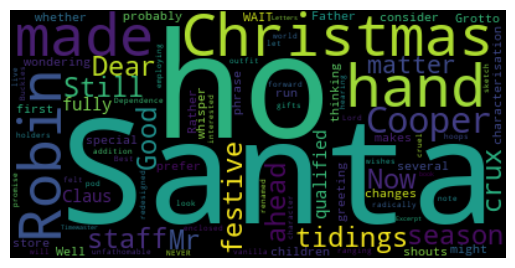

In [109]:
word_cloud = WordCloud().generate(email_body)
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [110]:
example_corpus = nltk.corpus.gutenberg.words('melville-moby_dick.txt')
len(example_corpus)

260819

In [111]:
type(example_corpus)

nltk.corpus.reader.util.StreamBackedCorpusView

In [112]:
example_corpus


['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', ...]

In [113]:
word_list = [''.join(word) for word in example_corpus]
novel_as_string = ''.join(word_list)

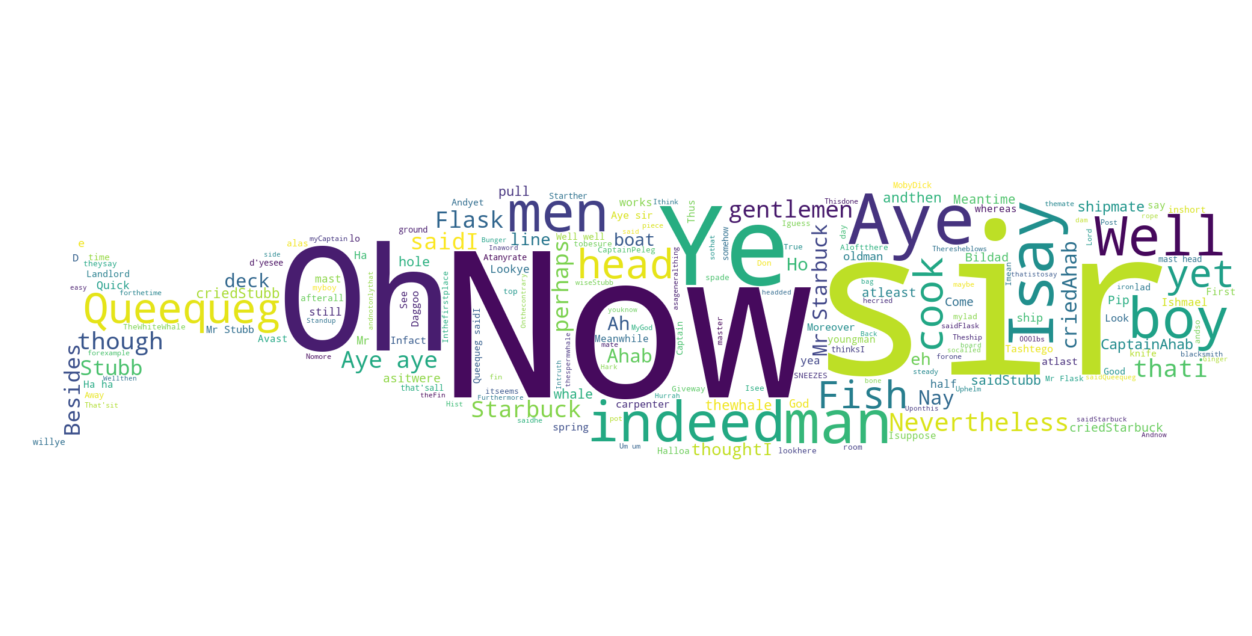

In [114]:
icon = Image.open(WHALE_FILE)
image_mask = Image.new(mode='RGB', size=icon.size, color=(255, 255, 255))
image_mask.paste(icon, box=icon)

rgb_array = np.array(image_mask) # converts the image object to an array

word_cloud = WordCloud(mask=rgb_array, background_color='white').generate(novel_as_string)

plt.figure(figsize=[16, 8])
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [115]:
rgb_array.shape

(1024, 2048, 3)

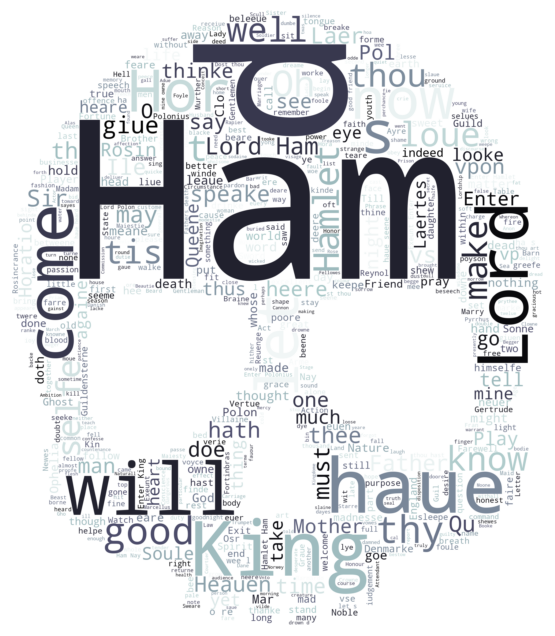

In [116]:
# Challenge: use the skull image in the lesson resources to create a word cloud
# for Shakespeare's play Hamlet

hamlet_corpus = nltk.corpus.gutenberg.words('shakespeare-hamlet.txt')
word_list = [''.join(word) for word in hamlet_corpus]
hamlet_as_string = ' '.join(word_list)

skull_icon = Image.open(SKULL_FILE)
image_mask = Image.new(mode='RGB', size=skull_icon.size, color=(255, 255, 255))
image_mask.paste(skull_icon, box=skull_icon)
rgb_array = np.array(image_mask)

word_cloud = WordCloud(mask=rgb_array, background_color='white',
                       colormap='bone', max_words=600)

word_cloud.generate(hamlet_as_string)

plt.figure(figsize=[12, 8])
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">Word Cloud of Ham and Spam Messages</span>

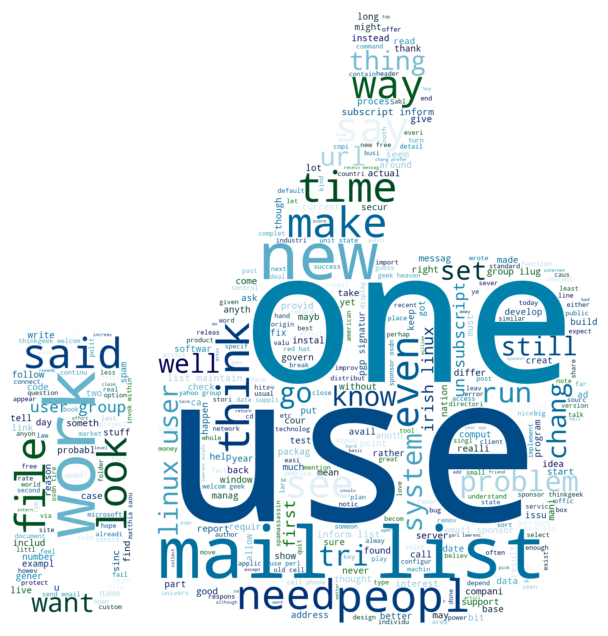

In [117]:
icon = Image.open(THUMBS_UP_FILE)
image_mask = Image.new(mode='RGB', size=icon.size, color=(255, 255, 255))
image_mask.paste(icon, box=icon)

rgb_array = np.array(image_mask) # converts the image object to an array

# Generate the text as a string for the word cloud
ham_str = ' '.join(flat_list_ham)

word_cloud = WordCloud(mask=rgb_array, background_color='white',
                       max_words=400, colormap='ocean')

word_cloud.generate(ham_str)

plt.figure(figsize=[16, 8])
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')   
plt.show()

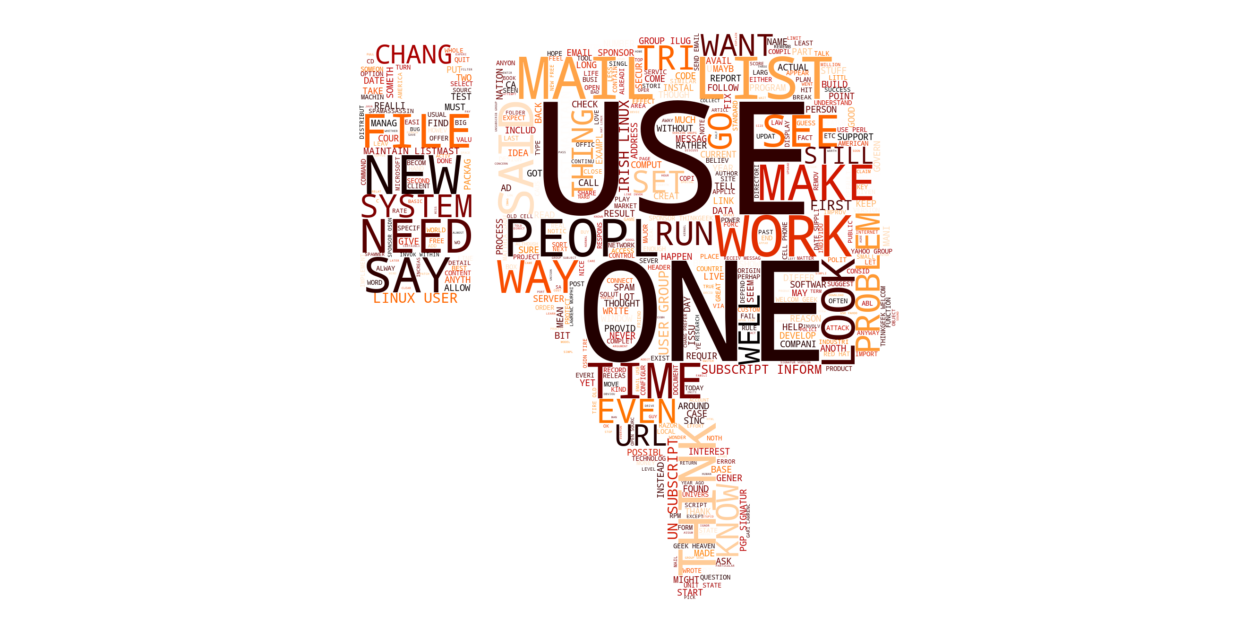

In [118]:
icon = Image.open(THUMBS_DOWN_FILE)
image_mask = Image.new(mode='RGB', size=icon.size, color=(255, 255, 255))
image_mask.paste(icon, box=icon)

rgb_array = np.array(image_mask) # converts the image object to an array

# Generate the text as a string for the word cloud
ham_str = ' '.join(flat_list_ham)

word_cloud = WordCloud(mask=rgb_array, background_color='white',
                       max_words=500, colormap='gist_heat')

word_cloud.generate(ham_str.upper())

plt.figure(figsize=[16, 8])
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')   
plt.show()

# <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">Generate Vocabulary & Dictionary</span>

In [119]:
stemmed_nested_list = data.MESSAGE.apply(clean_message_no_html)
flat_stemmed_list = [item for sublist in stemmed_nested_list for item in sublist]

In [120]:
# unique set of words in this series.
unique_words = pd.Series(flat_stemmed_list).value_counts()
print('Nr of unique words', unique_words.shape[0])
unique_words.head()

Nr of unique words 27300


http     10660
use       5015
list      4855
email     4365
get       4196
Name: count, dtype: int64

In [121]:
# most set of words in this series. 
frequent_words = unique_words[0:VOCAB_SIZE]
print('Most common words:', frequent_words[:10])

Most common words: http     10660
use       5015
list      4855
email     4365
get       4196
mail      3980
one       3904
free      3201
time      3038
work      2880
Name: count, dtype: int64


In [122]:
# it is pandas series .
type(frequent_words)

pandas.core.series.Series

# <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166"> Create Vocabulary DataFrame With A WORD_ID </span>


In [123]:
word_ids =list(range(0, VOCAB_SIZE))
vocab =pd.DataFrame({'VOCAB_WORD':frequent_words.index.values}, index=word_ids)
vocab.index.name = 'WORD_ID'
vocab.head()

,VOCAB_WORD
WORD_ID,
0,http
1,use
2,list
3,email
4,get



## <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166"> Save The Vocabulary As A CSV File  </span>


In [124]:
vocab.to_csv(WORD_ID_FILE, index_label=vocab.index.name, header=vocab.VOCAB_WORD.name)

In [125]:
# Challenge: Write a line of code that checks if a particular word is part
# of the vocabulary. Your code should return True if the word is among the
# 2,500 words that comprise the vocabulary, and False otherwise. Check these words:
# 'machine'
# 'learning'
# 'fun'
# 'learn'
# 'data'
# 'science'
# 'app'
# 'brewery'

In [126]:
any(vocab.VOCAB_WORD == 'machine') # inefficient

False

In [127]:
words_to_check = ['machine', 'learning', 'fun', 'learn', 'data', 'science', 'app', 'brewery']
for word in words_to_check:
    print(f"{word}: {word in vocab.VOCAB_WORD}")

machine: False
learning: False
fun: False
learn: False
data: False
science: False
app: False
brewery: False


In [128]:
clean_email_lengths = []
for sublist in stemmed_nested_list:
    clean_email_lengths.append(len(sublist))

In [129]:
# python list comprehension .
clean_email_lengths = [len(sublist) for sublist in stemmed_nested_list] 
print('Nr words in the longest email:', max(clean_email_lengths))

Nr words in the longest email: 7679


In [130]:
clean_email_lengths = [len(sublist) for sublist in stemmed_nested_list]
print('Nr words in the shortest email:', min(clean_email_lengths))

Nr words in the shortest email: 0


In [131]:
# argmax it gives the location of the largest value in this list.
print('Email position in the list (and the data frame)', np.argmax(clean_email_lengths))

Email position in the list (and the data frame) 5397


In [132]:
stemmed_nested_list[ np.argmax(clean_email_lengths)]

['yahoo',
 'group',
 'sponsor',
 'dvd',
 'free',
 'p',
 'join',
 'http',
 'new',
 'version',
 'unison',
 'avail',
 'test',
 'incorpor',
 'sever',
 'small',
 'improv',
 'main',
 'chang',
 'fix',
 'bug',
 'potenti',
 'seriou',
 'safeti',
 'consequ',
 'small',
 'number',
 'user',
 'habit',
 'run',
 'one',
 'instanc',
 'unison',
 'time',
 'parallel',
 'user',
 'strongli',
 'encourag',
 'upgrad',
 'other',
 'wait',
 'wish',
 'releas',
 'includ',
 'execut',
 'linux',
 'solari',
 'window',
 'look',
 'maintain',
 'moment',
 'none',
 'activ',
 'develop',
 'regularli',
 'use',
 'unison',
 'window',
 'machin',
 'configur',
 'properli',
 'build',
 'execut',
 'export',
 'grab',
 'http',
 'enjoy',
 'benjamin',
 'chang',
 'sinc',
 'ad',
 'prefer',
 'maxthread',
 'use',
 'limit',
 'number',
 'simultan',
 'file',
 'transfer',
 'ad',
 'backupdir',
 'prefer',
 'control',
 'backup',
 'file',
 'store',
 'basic',
 'support',
 'ad',
 'osx',
 'particular',
 'unison',
 'recogn',
 'one',
 'host',
 'synchron',
 

In [133]:
# tells the row name .
data.at[np.argmax(clean_email_lengths), 'MESSAGE']

'------------------------ Yahoo! Groups Sponsor ---------------------~-->\n\n4 DVDs Free +s&p Join Now\n\nhttp://us.click.yahoo.com/pt6YBB/NXiEAA/Ey.GAA/26EolB/TM\n\n---------------------------------------------------------------------~->\n\n\n\nA new version of unison is now available for testing.  It incorporates\n\nseveral small improvements over 2.9.1, but the main change is a fix to\n\na bug that had potentially serious safety consequences, but only for\n\nthe very small number of users that are in the habit of running more\n\nthan one instance of Unison at a time, in parallel.  These users are\n\nstrongly encouraged to upgrade.  Others can wait if they wish.\n\n\n\nThe release includes pre-built executables for Linux and Solaris, but\n\nnot Windows.  (We are looking for a Unison-Windows maintainer -- at\n\nthe moment, none of the active developers are regularly using Unison\n\non Windows, and we do not have a machine that is configured properly\n\nfor building executables for exp

## <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">  Generate Features And A Space Matrix </span>

### <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166"> Creating A DataFrame With One Word Per Column  </span>


In [134]:
type(stemmed_nested_list)

pandas.core.series.Series

In [135]:
type(stemmed_nested_list.tolist())

list

In [136]:
word_column_df = pd.DataFrame.from_records(stemmed_nested_list.tolist())
word_column_df.head()

,0,1,2,3,4,5,6,7,8,9,...,7669,7670,7671,7672,7673,7674,7675,7676,7677,7678
0,dear,homeown,interest,rate,lowest,point,year,help,find,best,...,None,None,None,None,None,None,None,None,None,None
1,attent,must,comput,user,packag,deal,norton,systemwork,softwar,suit,...,None,None,None,None,None,None,None,None,None,None
2,messag,mime,format,dare,tri,find,better,annuiti,guarante,year,...,None,None,None,None,None,None,None,None,None,None
3,import,inform,new,domain,name,final,avail,gener,public,discount,...,None,None,None,None,None,None,None,None,None,None
4,bottom,line,give,away,cd,free,peopl,like,one,month,...,None,None,None,None,None,None,None,None,None,None


In [137]:
# 5796 is total numbers of email that we have.
# 7679 is number of words in the longest email.
word_column_df.shape 

(5795, 7679)


# <span style="color: #FF6B6B; font-family: Georgia; font-size: 45px; text-shadow: 1px 1px 2px #FFD166">✨ Traning And Test DataSet Split. ✨</span>

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(word_column_df, data.CATEGORY,
                                                    test_size=0.3, random_state=42)


In [ ]:
print('Nr Of Traning samples', X_train.shape[0])
print('Fraction of Traning set', X_train.shape[0] / word_column_df.shape[0])

In [ ]:
X_train.index.name = X_test.index.name = 'DOC_ID'
X_train.head()

In [ ]:
y_train.head()

## <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">  Create A Sparse Matrix For The Training Data.   </span>

In [ ]:
word_index = pd.Index(vocab.VOCAB_WORD)
type(word_index)

In [ ]:
word_index.get_loc('thu')

In [ ]:
import pandas as pd

def make_sparse_matrix(df, indexed_words, labels):
    """
    Converts a DataFrame of word occurrences into a sparse matrix representation.
    
    Args:
        df (pd.DataFrame): DataFrame with words as columns and document IDs as index (X_train/X_test).
        indexed_words (pd.Index): Unique words ordered by word ID.
        labels (pd.Series): Category labels for each document (y_train/y_test).
    
    Returns:
        pd.DataFrame: Sparse matrix with columns ['LABEL', 'DOC_ID', 'OCCURENCE', 'WORD_ID'].
    """
    # Get dimensions of input DataFrame
    nr_rows = df.shape[0]                     # Number of Rows
    nr_cols = df.shape[1]                     # Number of words per columns
    word_set = set(indexed_words)
    # Initialize list to store sparse matrix entries
    dict_list = []

    for i in range(nr_rows):          # For each document
        for j in range(nr_cols):      # For each word position in document
            word = df.iat[i, j]       # Get word at current position
            
            # Check if word is in our vocabulary
            if word in word_set:
                doc_id = df.index[i]  # Get document ID
                word_id = indexed_words.get_loc(word)  # Get numeric word ID
                category = labels.at[doc_id]  # Get document's category
                
                # Create sparse matrix entry
                item = {
                    'LABEL': category,
                    'DOC_ID': doc_id,
                    'OCCURENCE': 1,     
                    'WORD_ID': word_id
                }
                dict_list.append(item)
    
    # Convert list of dicts to DataFrame
    return pd.DataFrame(dict_list)


# Example usage (commented out):
# X_train = pd.DataFrame(...)  # Your word data
# y_train = pd.Series(...)     # Your labels
# vocab = pd.Index(['word1', 'word2', ...])  # Your vocabulary
# sparse_df = make_sparse_matrix(X_train, vocab, y_train)

In [ ]:
%%time
sparse_train_df = make_sparse_matrix(X_train, word_index, y_train)

In [ ]:
sparse_train_df[:5]

In [ ]:
sparse_train_df.shape

In [ ]:
sparse_train_df[-5:]

### <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166"> Combine Occurrences with the Pandas groupby() Method </span>

In [ ]:
train_grouped = sparse_train_df.groupby(['DOC_ID', 'WORD_ID','LABEL']).sum()
train_grouped.head()

In [ ]:
vocab.at[0,'VOCAB_WORD']

In [ ]:
 data.MESSAGE[0]

In [ ]:
train_grouped = train_grouped.reset_index()
train_grouped.head()

In [ ]:
train_grouped.tail()

In [ ]:
vocab.at[1923, 'VOCAB_WORD']

In [ ]:
data.MESSAGE[5795]

In [ ]:
train_grouped.shape

### <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">  Save Training Data as .txt File  </span>


In [ ]:
np.savetxt(TRAINING_DATA_FILE, train_grouped, fmt='%d')

In [ ]:
train_grouped.columns


# <span style="color: #FF6B6B; font-family: Georgia; font-size: 45px; text-shadow: 1px 1px 2px #FFD166">✨ Testing ✨</span>

In [ ]:
X_test.head()

In [ ]:
y_test.head()

In [ ]:
X_test.shape

In [ ]:
%%time
sparse_test_df = make_sparse_matrix(X_test, word_index,y_test)

In [ ]:
sparse_test_df.shape

In [ ]:
test_grouped = sparse_test_df.groupby(['DOC_ID','WORD_ID','LABEL']).sum().reset_index()
test_grouped.head()

In [ ]:
test_grouped.shape

### saving file.


In [ ]:
np.savetxt(TEST_DATA_FILE, test_grouped, fmt='%d')

### <span style="color: #3674B5; font-family: Georgia; font-size: 28px; text-shadow: 1px 1px 2px #FFD166">  Pre-Processing Subtleties and Checking your Understanding</span>

Challenge: We started with 5796 emails. We split it into 4057 emails for training and 1739 emails for testing.

How many individual emails were included in the testing .txt file? Count the number in the test_grouped DataFrame.
After splitting and shuffling our data, how many emails were included in the X_test DataFrame? 
Is the number the same? If not, which emails were excluded and why? Compare the DOC_ID values to find out.

In [ ]:
train_doc_ids = set(train_grouped.DOC_ID)
test_doc_ids = set(test_grouped.DOC_ID)

In [ ]:
len(train_doc_ids)

In [ ]:
len(test_doc_ids)

In [ ]:
len(X_test)

In [ ]:
clean_message_no_html(data.at[14,'MESSAGE'])

In [ ]:
data.MESSAGE[1096]

In [ ]:
clean_message(data.at[1096, 'MESSAGE'])